In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
df = pd.read_excel("Desafio+Prático+III.xlsx")

In [3]:
df.head(10)

,ID_Produto,Categoria,Preco_R$,Quantidade_Vendida,Data_Venda
0,101.0,Eletrônicos,2500.0,5.0,2024-01-05
1,102.0,Eletrônicos,2200.0,8.0,2024-01-07
2,103.0,Moda,150.0,25.0,2024-02-01
3,104.0,Moda,200.0,18.0,2024-02-15
4,105.0,Beleza,90.0,32.0,2024-03-10
5,106.0,Beleza,120.0,28.0,2024-03-22
6,107.0,Esportes,300.0,15.0,2024-04-05
7,108.0,Esportes,280.0,20.0,2024-04-12
8,109.0,Eletrônicos,2100.0,10.0,2024-05-05
9,110.0,Casa,450.0,12.0,2024-05-18


In [4]:
df.shape # 50 Linhas e 5 colunas

(50, 5)

In [5]:
df.dtypes

ID_Produto                   float64
Categoria                     object
Preco_R$                     float64
Quantidade_Vendida           float64
Data_Venda            datetime64[ns]
dtype: object

In [6]:
df.isnull().sum()/len(df)

ID_Produto            0.0
Categoria             0.0
Preco_R$              0.0
Quantidade_Vendida    0.0
Data_Venda            0.0
dtype: float64

In [7]:
df.duplicated().sum()

0

In [8]:
df['ID_Produto'] = df['ID_Produto'].astype('int64')
df['Quantidade_Vendida'] = df['Quantidade_Vendida'].astype('int64')
df.dtypes

ID_Produto                     int64
Categoria                     object
Preco_R$                     float64
Quantidade_Vendida             int64
Data_Venda            datetime64[ns]
dtype: object

In [9]:
df.head(10)

,ID_Produto,Categoria,Preco_R$,Quantidade_Vendida,Data_Venda
0,101,Eletrônicos,2500.0,5,2024-01-05
1,102,Eletrônicos,2200.0,8,2024-01-07
2,103,Moda,150.0,25,2024-02-01
3,104,Moda,200.0,18,2024-02-15
4,105,Beleza,90.0,32,2024-03-10
5,106,Beleza,120.0,28,2024-03-22
6,107,Esportes,300.0,15,2024-04-05
7,108,Esportes,280.0,20,2024-04-12
8,109,Eletrônicos,2100.0,10,2024-05-05
9,110,Casa,450.0,12,2024-05-18


In [10]:
# Estatística descritiva
media = df['Preco_R$'].mean()
mediana = df['Preco_R$'].median()
moda = df['Preco_R$'].mode().to_list()
desvio_padrao_populacional = df['Preco_R$'].std(ddof=0)
coeficiente_variacao = (desvio_padrao_populacional/media) * 100


print(f'Média dos preços: {media}\n'
      f'Mediana dos preços: {mediana:.2f}\n'
      f'Desvio padrão populacional dos preços: {desvio_padrao_populacional:.2f}\n'
      f'Coeficiente de variação dos preços: {coeficiente_variacao:.2f}%\n'
      f'Moda dos preços: {moda}')

if len(moda) == 1:
    print('Unimodal')
elif len(moda) > 1:
    print('Multimodal')
elif len(moda) == 0:
    print('Amodal')



Média dos preços: 752.1
Mediana dos preços: 305.00
Desvio padrão populacional dos preços: 854.50
Coeficiente de variação dos preços: 113.61%
Moda dos preços: [120.0, 280.0, 300.0, 2100.0, 2200.0, 2300.0]
Multimodal


In [11]:
# Histograma para visualizar a distribuição dos preços
n = len(df['Preco_R$'])
numero_bins = int(np.ceil(1 + 3.322 * np.log10(n)))
amplitude_total = df['Preco_R$'].max() - df['Preco_R$'].min()
intervalo = amplitude_total/numero_bins
print(numero_bins)
print(df['Preco_R$'].min())
print(df['Preco_R$'].max())
print(np.ceil(intervalo))

intervalos = [90, 449, 808, 1167, 1526, 1885, 2244, 2603]


7
90.0
2600.0
359.0


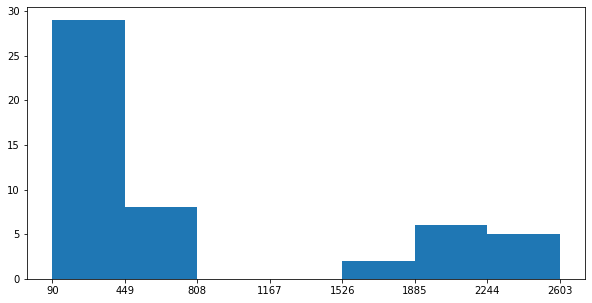

In [12]:
plt.figure(figsize = (10,5))
plt.hist(df['Preco_R$'], bins = intervalos)
plt.xticks(intervalos)
plt.show()

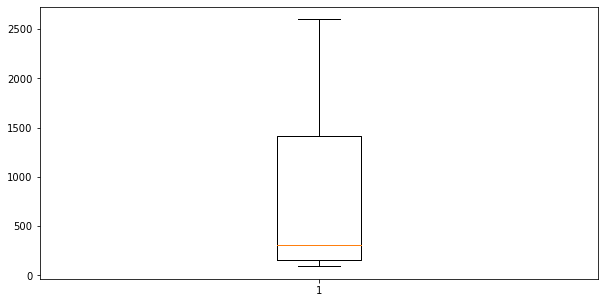

In [13]:
# Boxplot
plt.figure(figsize = (10,5))
plt.boxplot(df['Preco_R$'])
plt.show()

In [14]:
var = df['Preco_R$']
q1 = var.quantile(0.25)
q2 = var.quantile(0.50)
q3 = var.quantile(0.75)
iqr = q3 - q1
limite_superior = q3 + (1.5 * iqr)
limite_inferior = q1 - (1.5 * iqr)
outliers = var[(var > limite_superior) | (var < limite_inferior)]

In [15]:
print(q1)
print(q2)
print(q3)
print(iqr)
print(limite_superior)
print(limite_inferior)
print(outliers)

151.25
305.0
1412.5
1261.25
3304.375
-1740.625
Series([], Name: Preco_R$, dtype: float64)


In [16]:
# Analisando as categorias dos produtos
quantidade_vendida_categoria = df.groupby('Categoria')['Quantidade_Vendida'].sum().sort_values(ascending=False)
print(quantidade_vendida_categoria)

Categoria
Beleza         281
Moda           229
Esportes       191
Casa           101
Eletrônicos     87
Name: Quantidade_Vendida, dtype: int64


In [17]:
#Eletrônicos foi a categoria mais cara e menos vendida, com 87 unidades comercializadas.
#Isso se reflete na grande dispersão de valores em torno da mediana de R$ 305: 50% das vendas ficaram abaixo desse valor, 
#com mínimo de R$ 90 (uma faixa de baixa dispersão), enquanto os outros 50% ficaram acima, chegando a um máximo de R$ 2.600 (uma faixa de alta dispersão). 
# Beleza, Esportes, Moda e Casa, por sua natureza, concentram produtos mais baratos, porém mais vendidos. Somadas, essas categorias totalizam 802 unidades vendidas (281 + 229 + 191 + 101), com forte concentração de preços entre R$ 90 e R$ 449, uma faixa bem mais estreita e homogênea do que a observada em Eletrônicos.
df.head(10)

,ID_Produto,Categoria,Preco_R$,Quantidade_Vendida,Data_Venda
0,101,Eletrônicos,2500.0,5,2024-01-05
1,102,Eletrônicos,2200.0,8,2024-01-07
2,103,Moda,150.0,25,2024-02-01
3,104,Moda,200.0,18,2024-02-15
4,105,Beleza,90.0,32,2024-03-10
5,106,Beleza,120.0,28,2024-03-22
6,107,Esportes,300.0,15,2024-04-05
7,108,Esportes,280.0,20,2024-04-12
8,109,Eletrônicos,2100.0,10,2024-05-05
9,110,Casa,450.0,12,2024-05-18


In [18]:
mediana_qtd = df['Quantidade_Vendida'].median()
produtos_acima_mediana = df[df['Quantidade_Vendida'] > mediana_qtd]
preco_superior_200 = produtos_acima_mediana[(produtos_acima_mediana['Preco_R$'] > 200)]
faturamento_acima_6000 = preco_superior_200[
    preco_superior_200['Preco_R$'] * preco_superior_200['Quantidade_Vendida'] > 6000
]
print(faturamento_acima_6000.shape)

#  3 Produtos atenderam a esses critérios. Todos da categoria Esportes -> 6% das vendas

porcentagem_total = (len(faturamento_acima_6000)/len(df)) * 100
print(mediana_qtd)
print(porcentagem_total)

faturamento_acima_6000

(3, 5)
18.0
6.0


,ID_Produto,Categoria,Preco_R$,Quantidade_Vendida,Data_Venda
13,114,Esportes,320.0,22,2024-07-15
22,123,Esportes,310.0,21,2024-12-01
42,143,Esportes,280.0,23,2025-10-08
